In [1]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

sns.set_theme(style="ticks")
folder_path = r'D:\clone\merged'

In [2]:
def get_climate_data(filename):
    path = os.path.join(folder_path, filename)
    ds = xr.open_dataset(path)
    if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: ds = ds.mean(dim='expver')
    ds = ds.sortby('time')
    
    var_name = list(ds.data_vars)[0]
    data = ds[var_name]
    
    if 'temperature' in filename: data = data - 273.15
    
    ts_monthly = data.mean(dim=['latitude', 'longitude']).resample(time='1MS').mean().compute().to_dataframe(name=var_name)
    spatial_climatology = data.mean(dim='time').compute()
    
    yearly = data.resample(time='1YS').mean()
    spatial_trend = (yearly[-5:].mean(dim='time') - yearly[:5].mean(dim='time')).compute()
    
    raw_data_copy = data.compute()
    ds.close()
    gc.collect()
    
    return ts_monthly, spatial_climatology, spatial_trend, raw_data_copy, var_name

In [3]:
df_t2m, map_t2m, trend_t2m, raw_t2m, name_t2m = get_climate_data('2m_temperature_merged.nc')
df_t2m.head()

,number,t2m
time,,
1980-01-01,0,22.453865
1980-02-01,0,22.867079
1980-03-01,0,25.951124
1980-04-01,0,26.856434
1980-05-01,0,27.323635


In [4]:
df_tp, map_tp, trend_tp, raw_tp, name_tp = get_climate_data('mean_total_precipitation_rate_merged.nc')
df_tp.head()

,number,avg_tprate
time,,
1980-01-01,0,0.000010
1980-02-01,0,0.000013
1980-03-01,0,0.000015
1980-04-01,0,0.000028
1980-05-01,0,0.000073


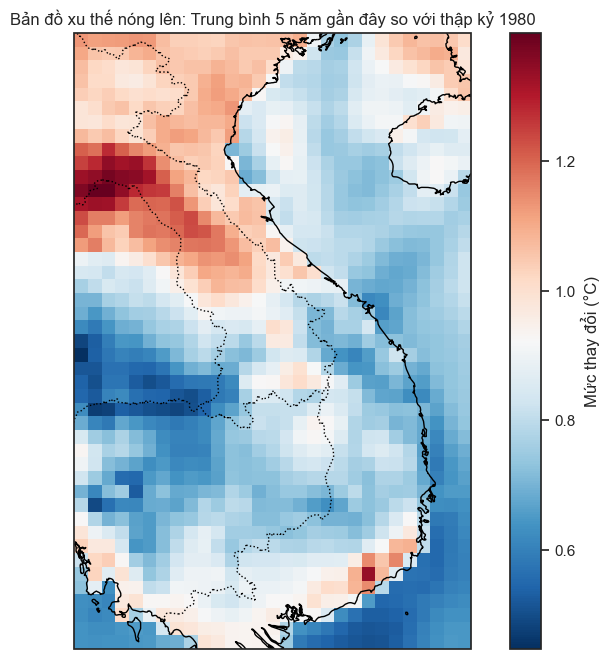

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')

trend_t2m.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', cbar_kwargs={'label': 'Mức thay đổi (°C)'})
plt.title("Bản đồ xu thế nóng lên: Trung bình 5 năm gần đây so với thập kỷ 1980")
plt.show()

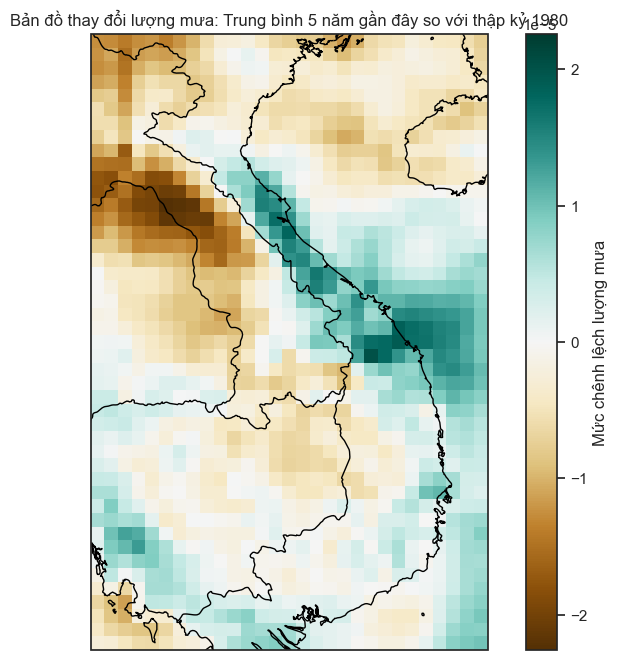

In [6]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

trend_tp.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='BrBG', cbar_kwargs={'label': 'Mức chênh lệch lượng mưa'})
plt.title("Bản đồ thay đổi lượng mưa: Trung bình 5 năm gần đây so với thập kỷ 1980")
plt.show()

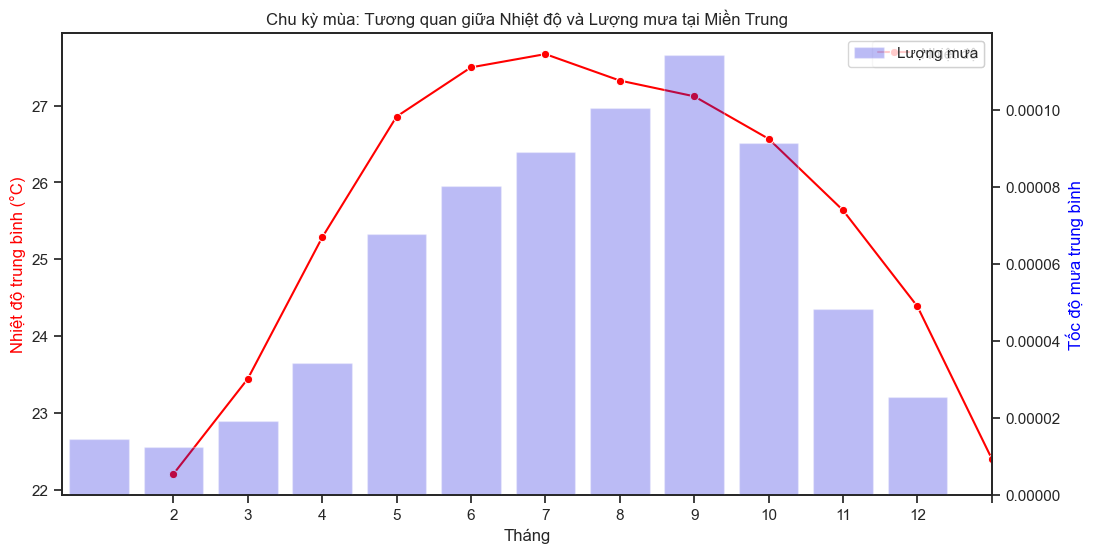

In [7]:
df_final = pd.concat([df_t2m, df_tp], axis=1).dropna()
df_final['Month'] = df_final.index.month
seasonal_cycle = df_final.groupby('Month').mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(data=seasonal_cycle, x=seasonal_cycle.index, y=name_t2m, ax=ax1, color='red', marker='o', label='Nhiệt độ')
sns.barplot(data=seasonal_cycle, x=seasonal_cycle.index, y=name_tp, ax=ax2, color='blue', alpha=0.3, label='Lượng mưa')

ax1.set_xlabel('Tháng')
ax1.set_ylabel('Nhiệt độ trung bình (°C)', color='red')
ax2.set_ylabel('Tốc độ mưa trung bình', color='blue')
plt.title("Chu kỳ mùa: Tương quan giữa Nhiệt độ và Lượng mưa tại Miền Trung")
plt.xticks(range(1, 13))
plt.show()

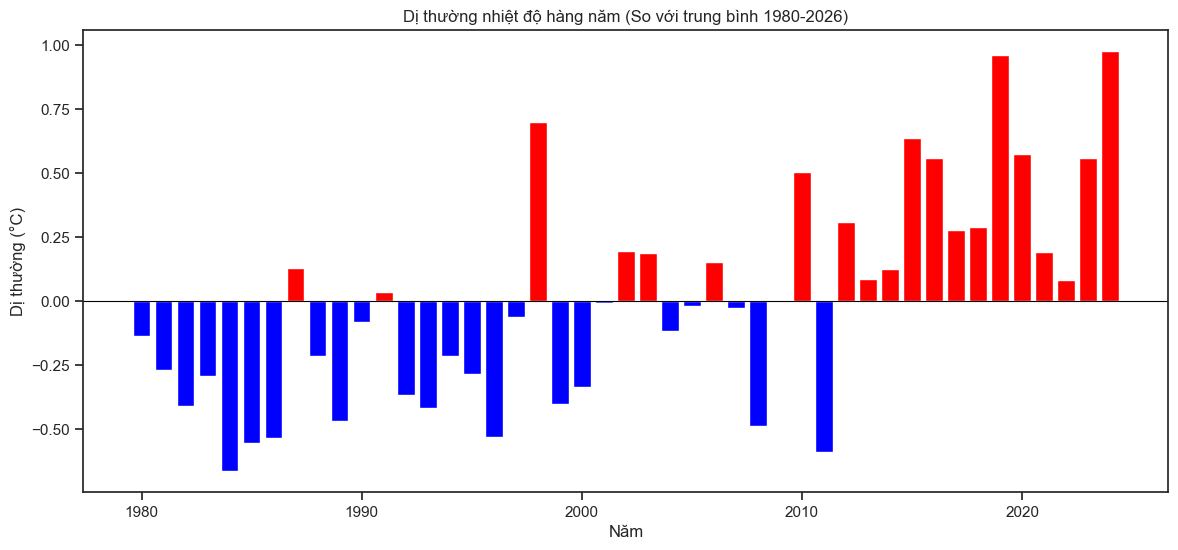

In [8]:
plt.figure(figsize=(14, 6))
df_yearly = df_final.resample('1YS').mean()
df_yearly['anomaly'] = df_yearly[name_t2m] - df_yearly[name_t2m].mean()

bar_colors = ['red' if x > 0 else 'blue' for x in df_yearly['anomaly']]
plt.bar(df_yearly.index.year, df_yearly['anomaly'], color=bar_colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Dị thường nhiệt độ hàng năm (So với trung bình 1980-2026)")
plt.xlabel("Năm")
plt.ylabel("Dị thường (°C)")
plt.show()

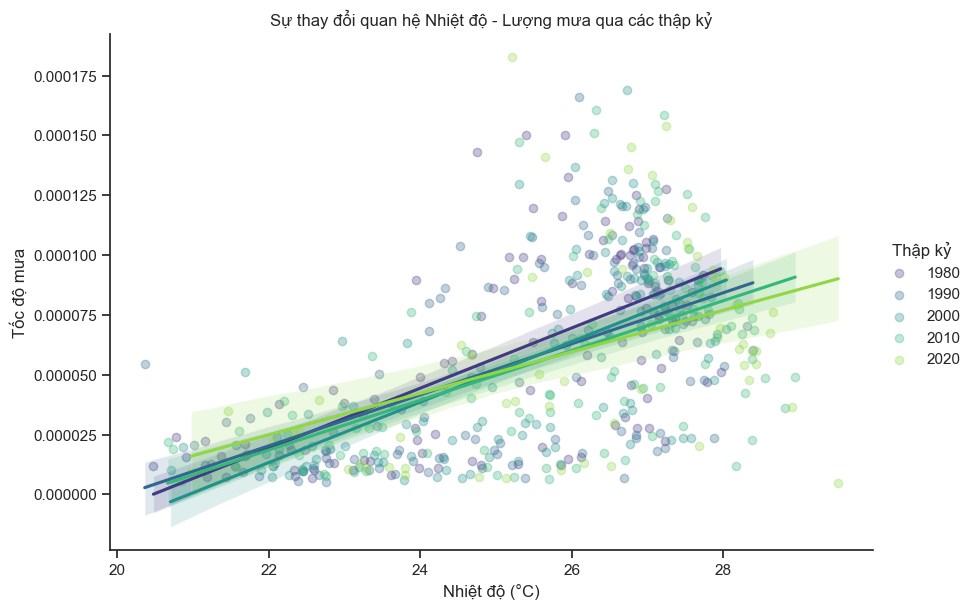

In [9]:
df_final['Decade'] = (df_final.index.year // 10) * 10
chart = sns.lmplot(data=df_final, x=name_t2m, y=name_tp, hue='Decade', 
                   palette='viridis', scatter_kws={'alpha':0.3}, height=6, aspect=1.5)
plt.title("Sự thay đổi quan hệ Nhiệt độ - Lượng mưa qua các thập kỷ")
plt.xlabel("Nhiệt độ (°C)")
plt.ylabel("Tốc độ mưa")
chart._legend.set_title("Thập kỷ")
plt.show()

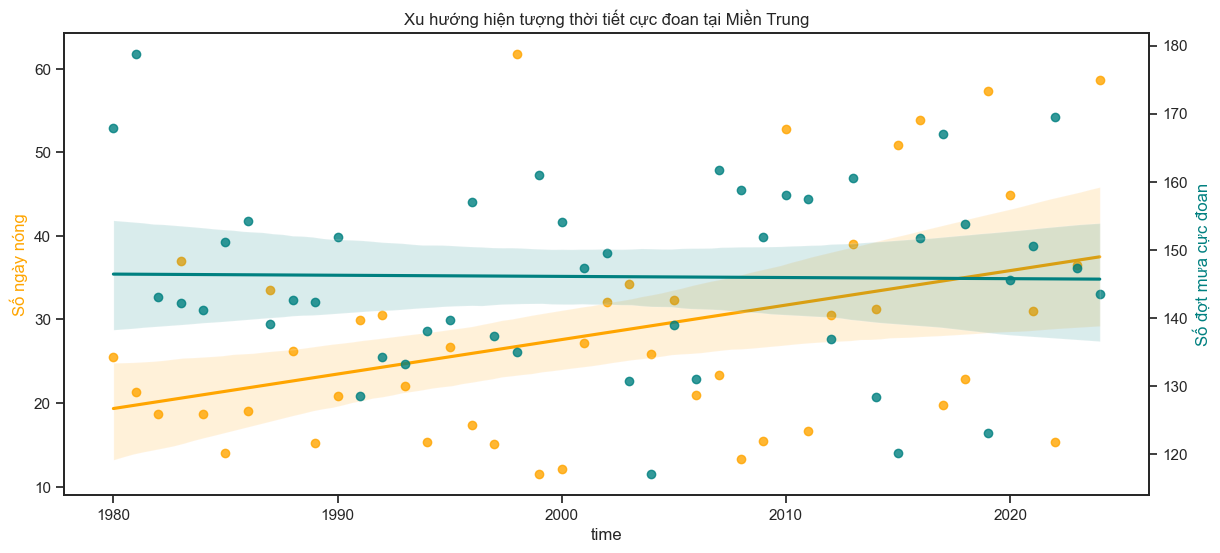

In [10]:
hot_days_ts = (raw_t2m > 35).resample(time='1YS').sum(dim='time').mean(dim=['latitude', 'longitude']).to_dataframe(name='hot')
heavy_rain_threshold = raw_tp.quantile(0.95)
heavy_rain_ts = (raw_tp > heavy_rain_threshold).resample(time='1YS').sum(dim='time').mean(dim=['latitude', 'longitude']).to_dataframe(name='rain')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.regplot(x=hot_days_ts.index.year, y=hot_days_ts['hot'], ax=ax1, color='orange', label='Ngày nắng nóng (>35°C)')
sns.regplot(x=heavy_rain_ts.index.year, y=heavy_rain_ts['rain'], ax=ax2, color='teal', label='Ngày mưa lớn')

ax1.set_ylabel("Số ngày nóng", color='orange')
ax2.set_ylabel("Số đợt mưa cực đoan", color='teal')
plt.title("Xu hướng hiện tượng thời tiết cực đoan tại Miền Trung")
plt.show()

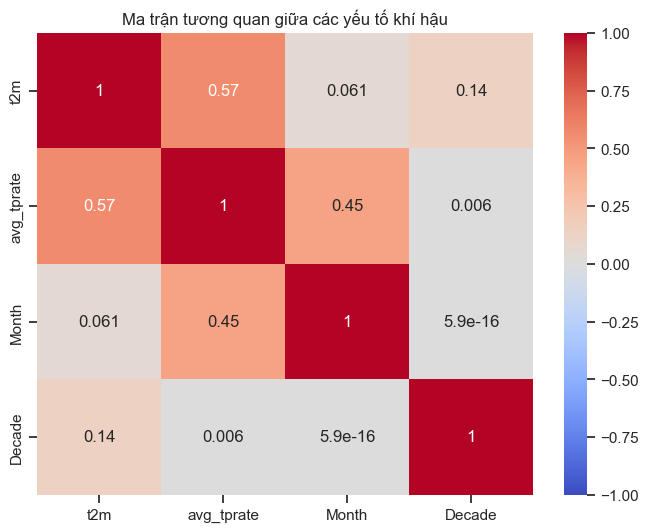

In [11]:
plt.figure(figsize=(8, 6))
cor_matrix = df_final[[name_t2m, name_tp, 'Month', 'Decade']].corr()
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các yếu tố khí hậu")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\2525401917.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_final, x=name_t2m, y=name_tp, cmap="Reds", shade=True, thresh=0.05)


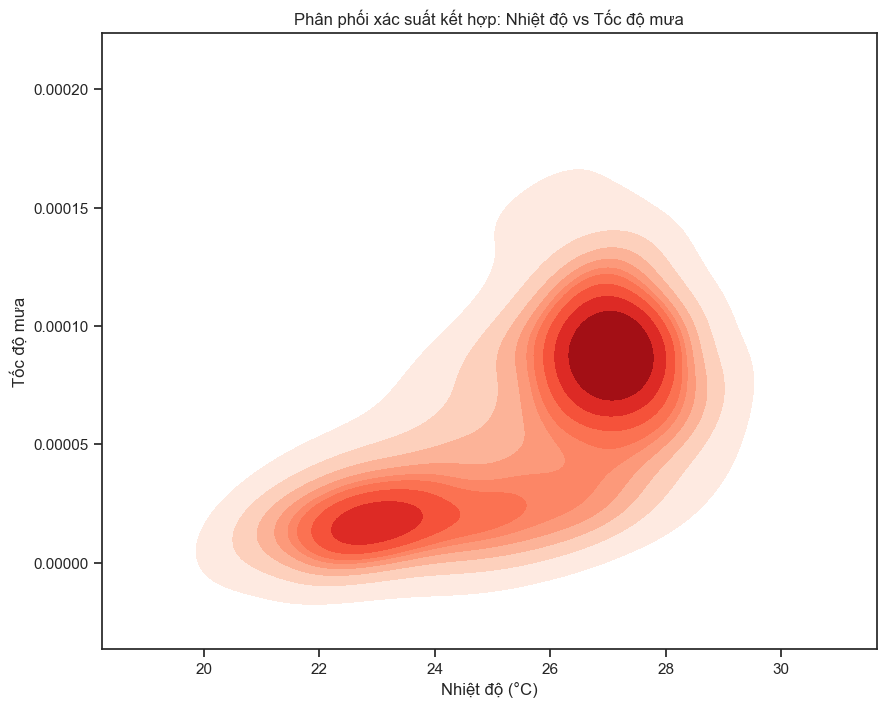

In [12]:
plt.figure(figsize=(10, 8))
sns.kdeplot(data=df_final, x=name_t2m, y=name_tp, cmap="Reds", shade=True, thresh=0.05)
plt.title("Phân phối xác suất kết hợp: Nhiệt độ vs Tốc độ mưa")
plt.xlabel("Nhiệt độ (°C)")
plt.ylabel("Tốc độ mưa")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\3498778031.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_80s[name_t2m], label='Thập kỷ 1980', color='blue', shade=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\3498778031.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_20s[name_t2m], label='Thập kỷ 2020', color='red', shade=True)


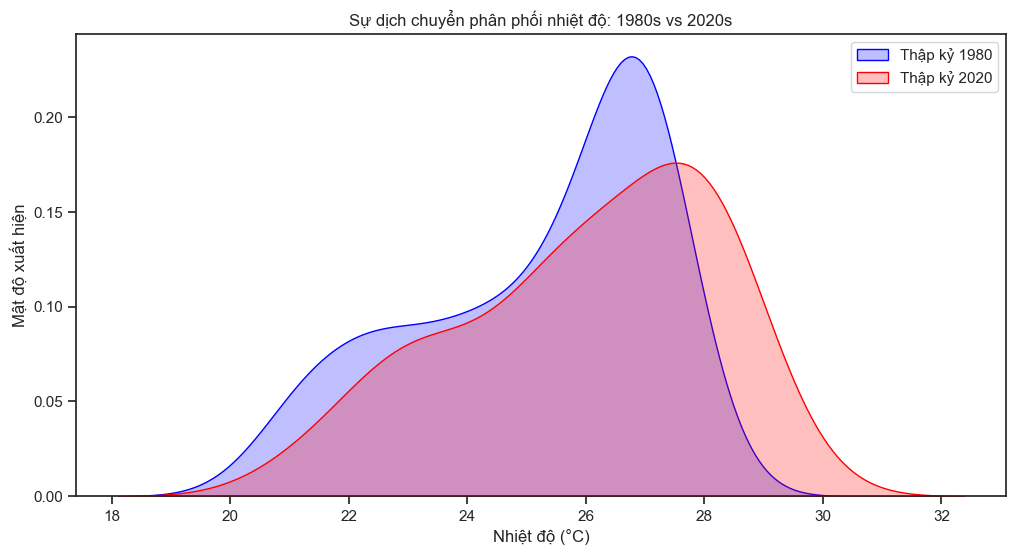

In [14]:
plt.figure(figsize=(12, 6))
df_80s = df_final[df_final['Decade'] == 1980]
df_20s = df_final[df_final['Decade'] == 2020]

sns.kdeplot(df_80s[name_t2m], label='Thập kỷ 1980', color='blue', shade=True)
sns.kdeplot(df_20s[name_t2m], label='Thập kỷ 2020', color='red', shade=True)

plt.title("Sự dịch chuyển phân phối nhiệt độ: 1980s vs 2020s")
plt.xlabel("Nhiệt độ (°C)")
plt.ylabel("Mật độ xuất hiện")
plt.legend()
plt.show()

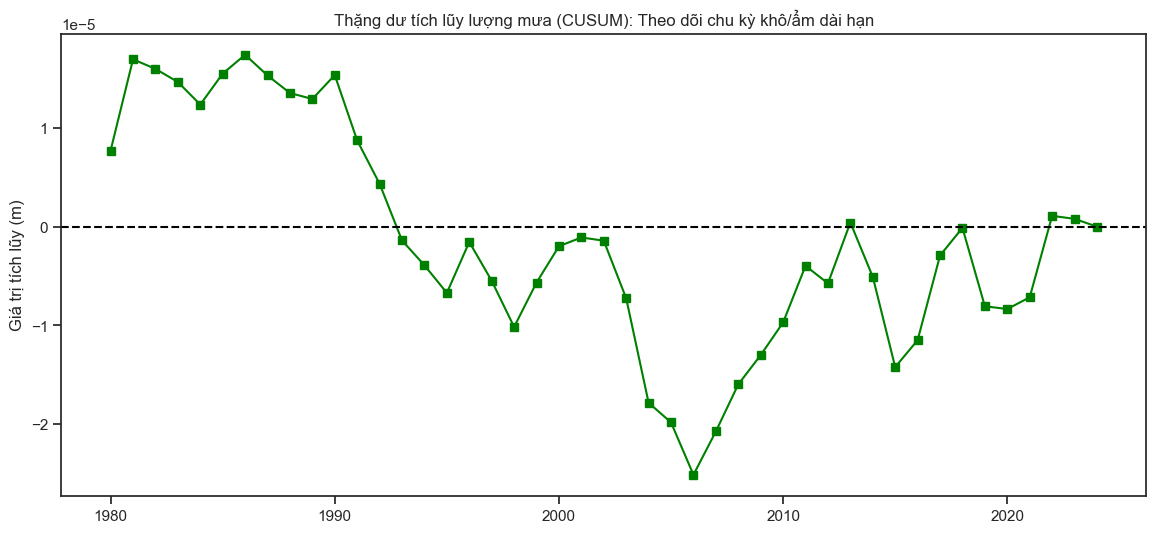

In [15]:
df_yearly_precip = df_final[name_tp].resample('1YS').mean()
precip_cusum = (df_yearly_precip - df_yearly_precip.mean()).cumsum()

plt.figure(figsize=(14, 6))
plt.plot(precip_cusum.index.year, precip_cusum, marker='s', color='green')
plt.axhline(0, color='black', linestyle='--')
plt.title("Thặng dư tích lũy lượng mưa (CUSUM): Theo dõi chu kỳ khô/ẩm dài hạn")
plt.ylabel("Giá trị tích lũy (m)")
plt.show()

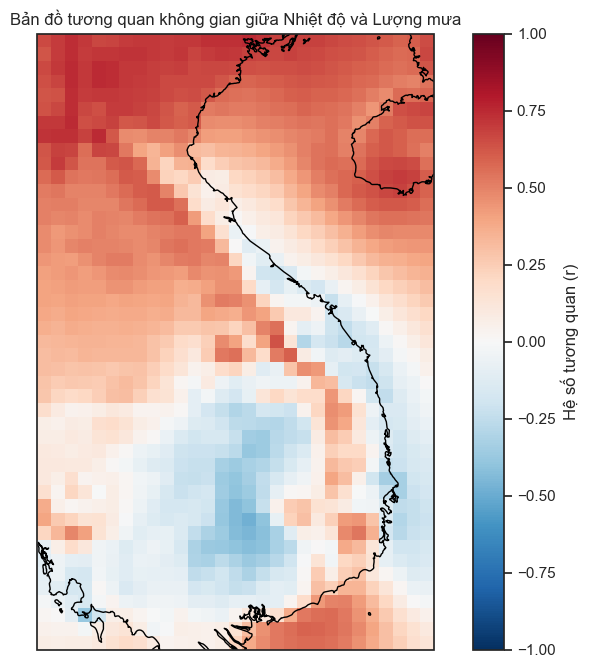

In [16]:
# Lưu ý: Box này cần dữ liệu raw_t2m và raw_tp đã compute ở Box trước
t_resampled = raw_t2m.resample(time='1MS').mean()
p_resampled = raw_tp.resample(time='1MS').mean()

spatial_corr_map = xr.corr(t_resampled, p_resampled, dim='time').compute()

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

spatial_corr_map.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-1, vmax=1,
                      cbar_kwargs={'label': 'Hệ số tương quan (r)'})
plt.title("Bản đồ tương quan không gian giữa Nhiệt độ và Lượng mưa")
plt.show()